In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Import and pre-process data

In [2]:
csv_path = "VAI_HW_CLIP_Image_Vecs-1.csv"

df = pd.read_csv(csv_path, header=None)
X = df.values.astype(np.float32)

print("X shape:", X.shape)

# Creating True labels array:
# first 100 -> class 0
# second 100 -> class 1
# last 100 -> class 2
y = np.array([0]*100 + [1]*100 + [2]*100, dtype=np.int64)

print("y shape:", y.shape)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

full_dataset = TensorDataset(X_tensor, y_tensor)
full_loader = DataLoader(full_dataset, batch_size=32, shuffle=True)

X shape: (300, 1568)
y shape: (300,)


### C Model

In [3]:
class DenseClassifier(nn.Module):
    def __init__(self, input_dim=1568, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


C = DenseClassifier(input_dim=1568, num_classes=3).to(device)

criterion_C = nn.CrossEntropyLoss()
optimizer_C = optim.Adam(C.parameters(), lr=1e-3, weight_decay=1e-4)

### Training Classifier C

In [4]:
num_epochs_cls = 80

for epoch in range(num_epochs_cls):
    C.train()
    running_loss = 0.0

    for xb, yb in full_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer_C.zero_grad()
        logits = C(xb)
        loss = criterion_C(logits, yb)
        loss.backward()
        optimizer_C.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(full_dataset)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[C] Epoch {epoch+1:3d}/{num_epochs_cls}, Loss: {epoch_loss:.6f}")


[C] Epoch   1/80, Loss: 0.611206
[C] Epoch  10/80, Loss: 0.000416
[C] Epoch  20/80, Loss: 0.000363
[C] Epoch  30/80, Loss: 0.000317
[C] Epoch  40/80, Loss: 0.000087
[C] Epoch  50/80, Loss: 0.000052
[C] Epoch  60/80, Loss: 0.000060
[C] Epoch  70/80, Loss: 0.000096
[C] Epoch  80/80, Loss: 0.000135


### Evaluate Classifier C


CLASSIFICATION REPORT 1: Original 300 vectors
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     1.0000    1.0000    1.0000       100
           2     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       300
   macro avg     1.0000    1.0000    1.0000       300
weighted avg     1.0000    1.0000    1.0000       300

CONFUSION MATRIX 1:


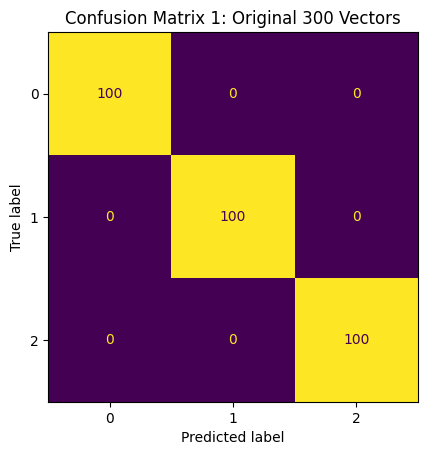

In [5]:
C.eval()
with torch.no_grad():
    logits_all = C(X_tensor.to(device))
    yhat1 = torch.argmax(logits_all, dim=1).cpu().numpy()

report1 = classification_report(y, yhat1, digits=4)
cm1 = confusion_matrix(y, yhat1)

print("\n" + "="*70)
print("CLASSIFICATION REPORT 1: Original 300 vectors")
print("="*70)
print(report1)

print("CONFUSION MATRIX 1:")
fig, ax = plt.subplots()

disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=[0, 1, 2])
disp.plot(ax=ax, values_format='d', colorbar=False)

ax.set_title("Confusion Matrix 1: Original 300 Vectors")
plt.show()

### VAE Model

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim=1568, hidden_dim=512, latent_dim=32):
        super().__init__()

        self.encoder_fc1 = nn.Linear(input_dim, hidden_dim)
        self.encoder_fc2 = nn.Linear(hidden_dim, 128)
        self.mu_layer = nn.Linear(128, latent_dim)
        self.logvar_layer = nn.Linear(128, latent_dim)

        self.decoder_fc1 = nn.Linear(latent_dim, 128)
        self.decoder_fc2 = nn.Linear(128, hidden_dim)
        self.decoder_out = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()

    def encode(self, x):
        h = self.relu(self.encoder_fc1(x))
        h = self.relu(self.encoder_fc2(h))
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.relu(self.decoder_fc1(z))
        h = self.relu(self.decoder_fc2(h))
        x_recon = self.decoder_out(h)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss_function(x_recon, x, mu, logvar, beta=0.1):
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction='mean')
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kld
    return total_loss, recon_loss, kld


vae = VAE(input_dim=1568, hidden_dim=512, latent_dim=32).to(device)
optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)

### Train VAE

In [7]:
num_epochs_vae = 120
beta = 0.1

for epoch in range(num_epochs_vae):
    vae.train()
    total_loss_epoch = 0.0
    recon_loss_epoch = 0.0
    kld_loss_epoch = 0.0

    for xb, _ in full_loader:
        xb = xb.to(device)

        optimizer_vae.zero_grad()
        x_recon, mu, logvar = vae(xb)
        loss, recon_loss, kld = vae_loss_function(x_recon, xb, mu, logvar, beta=beta)
        loss.backward()
        optimizer_vae.step()

        total_loss_epoch += loss.item() * xb.size(0)
        recon_loss_epoch += recon_loss.item() * xb.size(0)
        kld_loss_epoch += kld.item() * xb.size(0)

    total_loss_epoch /= len(full_dataset)
    recon_loss_epoch /= len(full_dataset)
    kld_loss_epoch /= len(full_dataset)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"[VAE] Epoch {epoch+1:3d}/{num_epochs_vae}, "
            f"Total: {total_loss_epoch:.6f}, "
            f"Recon: {recon_loss_epoch:.6f}, "
            f"KLD: {kld_loss_epoch:.6f}"
        )

[VAE] Epoch   1/120, Total: 0.672424, Recon: 0.659347, KLD: 0.130768
[VAE] Epoch  10/120, Total: 0.282229, Recon: 0.255345, KLD: 0.268846
[VAE] Epoch  20/120, Total: 0.222765, Recon: 0.186795, KLD: 0.359701
[VAE] Epoch  30/120, Total: 0.188303, Recon: 0.149639, KLD: 0.386638
[VAE] Epoch  40/120, Total: 0.166110, Recon: 0.123942, KLD: 0.421674
[VAE] Epoch  50/120, Total: 0.153673, Recon: 0.108553, KLD: 0.451205
[VAE] Epoch  60/120, Total: 0.141036, Recon: 0.096542, KLD: 0.444945
[VAE] Epoch  70/120, Total: 0.131634, Recon: 0.087322, KLD: 0.443121
[VAE] Epoch  80/120, Total: 0.123351, Recon: 0.080255, KLD: 0.430960
[VAE] Epoch  90/120, Total: 0.117041, Recon: 0.075806, KLD: 0.412354
[VAE] Epoch 100/120, Total: 0.110875, Recon: 0.070100, KLD: 0.407745
[VAE] Epoch 110/120, Total: 0.107315, Recon: 0.065304, KLD: 0.420109
[VAE] Epoch 120/120, Total: 0.102320, Recon: 0.060170, KLD: 0.421501


### Generate 30 samples via VAE

In [8]:
test_indices = np.random.choice(len(X), size=30, replace=False)

X_test_30 = X_tensor[test_indices]
y_test_30 = y_tensor[test_indices].numpy()

print("\nRandom 30 test indices:")
print(test_indices)

vae.eval()
with torch.no_grad():
    X_recon_30, _, _ = vae(X_test_30.to(device))
    X_recon_30 = X_recon_30.cpu()


Random 30 test indices:
[245 138  40  16 115  26  33 191 272  49 234 210 162 173 167 261 289 219
  38 152  73  57 284  96 154 220  28  94 185 178]


### Evaluate Classifier C with new samples


CLASSIFICATION REPORT 2: 30 reconstructed vectors from VAE
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        11
           1     1.0000    1.0000    1.0000        10
           2     1.0000    1.0000    1.0000         9

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30

CONFUSION MATRIX 2:


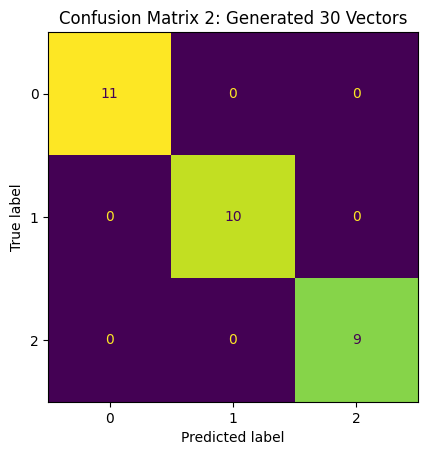

In [9]:
C.eval()
with torch.no_grad():
    logits_recon = C(X_recon_30.to(device))
    yhat2 = torch.argmax(logits_recon, dim=1).cpu().numpy()

report2 = classification_report(y_test_30, yhat2, digits=4)
cm2 = confusion_matrix(y_test_30, yhat2)

print("\n" + "="*70)
print("CLASSIFICATION REPORT 2: 30 reconstructed vectors from VAE")
print("="*70)
print(report2)

print("CONFUSION MATRIX 2:")
fig, ax = plt.subplots()

disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=[0, 1, 2])
disp.plot(ax=ax, values_format='d', colorbar=False)

ax.set_title("Confusion Matrix 2: Generated 30 Vectors")
plt.show()